In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from warnings import filterwarnings
filterwarnings('ignore')


In [2]:

resumes = pd.read_csv("../data/Resume.csv")
print(resumes.shape)
resumes.head()

(2484, 4)


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [3]:
# Count how many resumes exist per category (e.g. HR, Data Science, etc.)
# This returns a Series sorted by count, descending
print(resumes["Category"].value_counts())

# nunique() counts distinct category labels — tells us how many job categories we're working with
print(f"\nNumber of unique categories: {resumes['Category'].nunique()}")

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

Number of unique categories: 24


In [4]:
# nrows=0 tells pandas: don't load any data rows, just read the header line
# This is critical for a 500MB file — instant and uses almost no memory
cols_preview = pd.read_csv("../data/postings.csv", nrows=0).columns.tolist()

# Print the column names so we can decide which ones we actually need
print(cols_preview)

['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips']


In [5]:
# usecols tells pandas to only read these columns from disk — skips loading
# 20+ irrelevant columns (salary, tracking IDs, etc.), which matters a lot on a 500MB file
cols_needed = ["job_id", "title", "description", "formatted_experience_level", 
               "skills_desc", "location", "work_type"]

postings = pd.read_csv("../data/postings.csv", usecols=cols_needed)

# Check how much memory this actually used, and confirm row count
print(postings.shape)
postings.info(memory_usage="deep")

(123849, 7)
<class 'pandas.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 7 columns):
 #   Column                      Non-Null Count   Dtype
---  ------                      --------------   -----
 0   job_id                      123849 non-null  int64
 1   title                       123849 non-null  str  
 2   description                 123842 non-null  str  
 3   location                    123849 non-null  str  
 4   formatted_experience_level  94440 non-null   str  
 5   skills_desc                 2439 non-null    str  
 6   work_type                   123849 non-null  str  
dtypes: int64(1), str(6)
memory usage: 842.3 MB


In [6]:
# Look at a sample title + description to understand the text format
print(postings["title"].head(10))
print("\n---\n")
print(postings["description"].iloc[0])

0                                Marketing Coordinator
1                    Mental Health Therapist/Counselor
2                          Assitant Restaurant Manager
3    Senior Elder Law / Trusts and Estates Associat...
4                                   Service Technician
5             Economic Development and Planning Intern
6                                             Producer
7                                    Building Engineer
8                                Respiratory Therapist
9                                       Worship Leader
Name: title, dtype: str

---

Job descriptionA leading real estate firm in New Jersey is seeking an administrative Marketing Coordinator with some experience in graphic design. You will be working closely with our fun, kind, ambitious members of the sales team and our dynamic executive team on a daily basis. This is an opportunity to be part of a fast-growing, highly respected real estate brokerage with a reputation for exceptional marketing and 

In [7]:
# Drop skills_desc — 98% missing, not usable as a feature
postings = postings.drop(columns=["skills_desc"])

# Drop rows with missing description — can't use a job we can't read
postings = postings.dropna(subset=["description"])

# Sample down to 8,000 rows for fast iteration during development.
# random_state=42 makes the sample reproducible — same rows every time you rerun it
postings_sample = postings.sample(n=8000, random_state=42).reset_index(drop=True)

print(postings_sample.shape)
postings_sample.head()

(8000, 6)


,job_id,title,description,location,formatted_experience_level,work_type
0,3902931205,Warehouse,"Warehouse Associate\n\nSince 2022, Associated ...","Spokane, WA",Entry level,FULL_TIME
1,3894855473,Influencer Talent Manager - Beauty,Interested in joining our influencer talent ma...,"Atlanta, GA",NaN,FULL_TIME
2,3899525675,Talent Attraction Specialist,Talent Specialist - Hybrid Role Must be locate...,"Greenville, SC",Entry level,FULL_TIME
3,3887106339,Retail Sales - Shoes - Stonebriar Centre,The ideal Salesperson is passionate about fash...,"Frisco, TX",Entry level,FULL_TIME
4,3894555810,"Physician Assistant, Per Diem - Internal Medicine",1126363_RR00090444 Job ID: 1126363_RR00090444\...,"Mineola, NY",NaN,TEMPORARY


In [8]:
from sentence_transformers import SentenceTransformer

# 'all-MiniLM-L6-v2' is a small, fast, well-regarded model for semantic similarity
# It converts any text into a 384-dimensional vector that captures meaning, not just keywords
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [9]:
# If this prints without error, the model loaded successfully
print(model)
print("Embedding dimension:", model.get_sentence_embedding_dimension())

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({})
)
Embedding dimension: 384


In [10]:
# Grab one resume from each of two very different categories
ds_resume = resumes[resumes["Category"] == "INFORMATION-TECHNOLOGY"]["Resume_str"].iloc[0]
chef_resume = resumes[resumes["Category"] == "CHEF"]["Resume_str"].iloc[0]

# Grab one job posting title+description to test against
test_job = postings_sample["title"].iloc[0] + " " + postings_sample["description"].iloc[0]

# encode() turns text into a vector
embeddings = model.encode([ds_resume, chef_resume, test_job])

from sklearn.metrics.pairwise import cosine_similarity

sim_ds = cosine_similarity([embeddings[0]], [embeddings[2]])[0][0]
sim_chef = cosine_similarity([embeddings[1]], [embeddings[2]])[0][0]

print(f"Job title: {postings_sample['title'].iloc[0]}")
print(f"IT resume similarity: {sim_ds:.4f}")
print(f"Chef resume similarity: {sim_chef:.4f}")

Job title: Warehouse
IT resume similarity: 0.3483
Chef resume similarity: 0.1807


In [11]:
# Combine job title + description into one text field for each posting
# (title alone is too short to capture meaning well)
postings_sample["text"] = postings_sample["title"] + " " + postings_sample["description"]


In [12]:
if os.path.exists("../data/job_embeddings.npy"):
    # Already computed — just load it, instant
    job_embeddings = np.load("../data/job_embeddings.npy")
    print("Loaded cached embeddings:", job_embeddings.shape)
else:
    # First time — compute and save
    job_embeddings = model.encode(postings_sample["text"].tolist(), show_progress_bar=True)
    np.save("../data/job_embeddings.npy", job_embeddings)
    print("Computed and saved embeddings:", job_embeddings.shape)

Loaded cached embeddings: (8000, 384)


In [ ]:
def find_top_matches(resume_text, job_embeddings, postings_df, top_n=5):
    """
    Given a resume's text, find the top_n most similar job postings.
    """
    # Encode the single resume into a vector (same 384-dim space as the jobs)
    resume_embedding = model.encode([resume_text])
    
    # Compare this one resume vector against all 8,000 job vectors at once
    # Returns an array of 8,000 similarity scores
    similarities = cosine_similarity(resume_embedding, job_embeddings)[0]
    
    # Get the indices of the top_n highest scores, sorted descending
    top_indices = similarities.argsort()[::-1][:top_n]
    
    # Build a small results table: job title, score, and a preview of the description
    results = postings_df.iloc[top_indices][["title", "location"]].copy()
    results["similarity_score"] = similarities[top_indices]
    return results.reset_index(drop=True)

# Test it on a Data Science resume
sample_resume = resumes[resumes["Category"] == "INFORMATION-TECHNOLOGY"]["Resume_str"].iloc[0]
top_matches = find_top_matches(sample_resume, job_embeddings, postings_sample, top_n=5)
print(top_matches)

                                               title         location  \
0                Information Technology Risk Manager       Dallas, TX   
1        Information Systems Security Manager (ISSM)   Washington, DC   
2  Senior Quality Assurance Analyst-ProdDev Bay Area   Pleasanton, CA   
3        Information System Security Engineer (ISSE)      Herndon, VA   
4                                    Project Manager  Morrisville, NC   

   similarity_score  
0          0.627805  
1          0.627031  
2          0.622924  
3          0.607721  
4          0.599118  


In [14]:
test_categories = ["CHEF", "FINANCE", "HEALTHCARE"]

for cat in test_categories:
    sample = resumes[resumes["Category"] == cat]["Resume_str"].iloc[0]
    matches = find_top_matches(sample, job_embeddings, postings_sample, top_n=3)
    print(f"\n=== {cat} resume — top 3 matches ===")
    print(matches[["title", "similarity_score"]])


=== CHEF resume — top 3 matches ===
                                      title  similarity_score
0                                      Cook          0.613681
1  Join Our Culinary Team - City Cruises DC          0.601023
2                                    200052          0.583507

=== FINANCE resume — top 3 matches ===
                      title  similarity_score
0        Financial Director          0.730765
1           Finance Manager          0.688067
2  Finance Business Partner          0.685310

=== HEALTHCARE resume — top 3 matches ===
                                               title  similarity_score
0  Certified Nurse Assistant/Patient Care Assista...          0.560152
1                                   Registered Nurse          0.557167
2                       Registered Nurse - RN - LTAC          0.550833


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Features: TF-IDF representation of resume text
# max_features caps vocabulary size to keep it fast and avoid overfitting on rare words
tfidf = TfidfVectorizer(max_features=1000, stop_words="english", min_df=2)
X = tfidf.fit_transform(resumes["Resume_str"])
y = resumes["Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (1987, 1000) Test size: (497, 1000)


In [16]:
C_values = [0.05, 0.1, 0.2, 0.3, 0.5]

for c in C_values:
    clf = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced", C=c)
    clf.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    print(f"C={c}: Train={train_acc:.4f}, Test={test_acc:.4f}, Gap={train_acc - test_acc:.4f}")

C=0.05: Train=0.6356, Test=0.6197, Gap=0.0159
C=0.1: Train=0.6512, Test=0.6298, Gap=0.0215
C=0.2: Train=0.6855, Test=0.6459, Gap=0.0396
C=0.3: Train=0.7056, Test=0.6439, Gap=0.0617
C=0.5: Train=0.7423, Test=0.6539, Gap=0.0884


In [17]:
clf = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced", C=0.2)
clf.fit(X_train, y_train)

train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, clf.predict(X_test))
print(f"Final model — Train: {train_acc:.4f}, Test: {test_acc:.4f}, Gap: {train_acc - test_acc:.4f}")

y_pred = clf.predict(X_test)
print("\n", classification_report(y_test, y_pred))

Final model — Train: 0.6855, Test: 0.6459, Gap: 0.0396

                         precision    recall  f1-score   support

            ACCOUNTANT       0.59      0.83      0.69        24
              ADVOCATE       0.50      0.46      0.48        24
           AGRICULTURE       0.78      0.54      0.64        13
               APPAREL       0.50      0.11      0.17        19
                  ARTS       0.67      0.19      0.30        21
            AUTOMOBILE       0.43      0.43      0.43         7
              AVIATION       0.86      0.75      0.80        24
               BANKING       0.93      0.57      0.70        23
                   BPO       0.50      0.50      0.50         4
  BUSINESS-DEVELOPMENT       0.45      0.75      0.56        24
                  CHEF       0.82      0.75      0.78        24
          CONSTRUCTION       0.86      0.86      0.86        22
            CONSULTANT       1.00      0.09      0.16        23
              DESIGNER       0.81      0.81   

In [18]:
if os.path.exists("../data/resume_embeddings.npy"):
    resume_embeddings = np.load("../data/resume_embeddings.npy")
    print("Loaded cached resume embeddings:", resume_embeddings.shape)
else:
    resume_embeddings = model.encode(resumes["Resume_str"].tolist(), show_progress_bar=True)
    np.save("../data/resume_embeddings.npy", resume_embeddings)
    print("Computed and saved resume embeddings:", resume_embeddings.shape)

Loaded cached resume embeddings: (2484, 384)


In [19]:
# Same target labels as before
y_emb = resumes["Category"]

# Split embeddings — same random_state=42 so it's a fair comparison against the TF-IDF version
X_train_emb, X_test_emb, y_train_emb, y_test_emb = train_test_split(
    resume_embeddings, y_emb, test_size=0.2, random_state=42, stratify=y_emb
)

print("Train:", X_train_emb.shape, "Test:", X_test_emb.shape)

Train: (1987, 384) Test: (497, 384)


In [20]:
clf_emb = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced", C=0.2)
clf_emb.fit(X_train_emb, y_train_emb)

train_acc_emb = accuracy_score(y_train_emb, clf_emb.predict(X_train_emb))
test_acc_emb = accuracy_score(y_test_emb, clf_emb.predict(X_test_emb))

print(f"Embeddings model — Train: {train_acc_emb:.4f}, Test: {test_acc_emb:.4f}, Gap: {train_acc_emb - test_acc_emb:.4f}")
print(f"\nTF-IDF model (for comparison) — Train: {train_acc:.4f}, Test: {test_acc:.4f}, Gap: {train_acc - test_acc:.4f}")

Embeddings model — Train: 0.7202, Test: 0.6901, Gap: 0.0300

TF-IDF model (for comparison) — Train: 0.6855, Test: 0.6459, Gap: 0.0396


In [21]:
y_pred_emb = clf_emb.predict(X_test_emb)
print(classification_report(y_test_emb, y_pred_emb))

                        precision    recall  f1-score   support

            ACCOUNTANT       0.68      0.88      0.76        24
              ADVOCATE       0.62      0.62      0.62        24
           AGRICULTURE       0.80      0.62      0.70        13
               APPAREL       0.75      0.16      0.26        19
                  ARTS       1.00      0.05      0.09        21
            AUTOMOBILE       0.67      0.29      0.40         7
              AVIATION       0.78      0.58      0.67        24
               BANKING       0.76      0.57      0.65        23
                   BPO       0.25      0.25      0.25         4
  BUSINESS-DEVELOPMENT       0.69      0.83      0.75        24
                  CHEF       0.91      0.83      0.87        24
          CONSTRUCTION       0.74      0.77      0.76        22
            CONSULTANT       0.85      0.48      0.61        23
              DESIGNER       0.74      0.95      0.83        21
         DIGITAL-MEDIA       0.61      

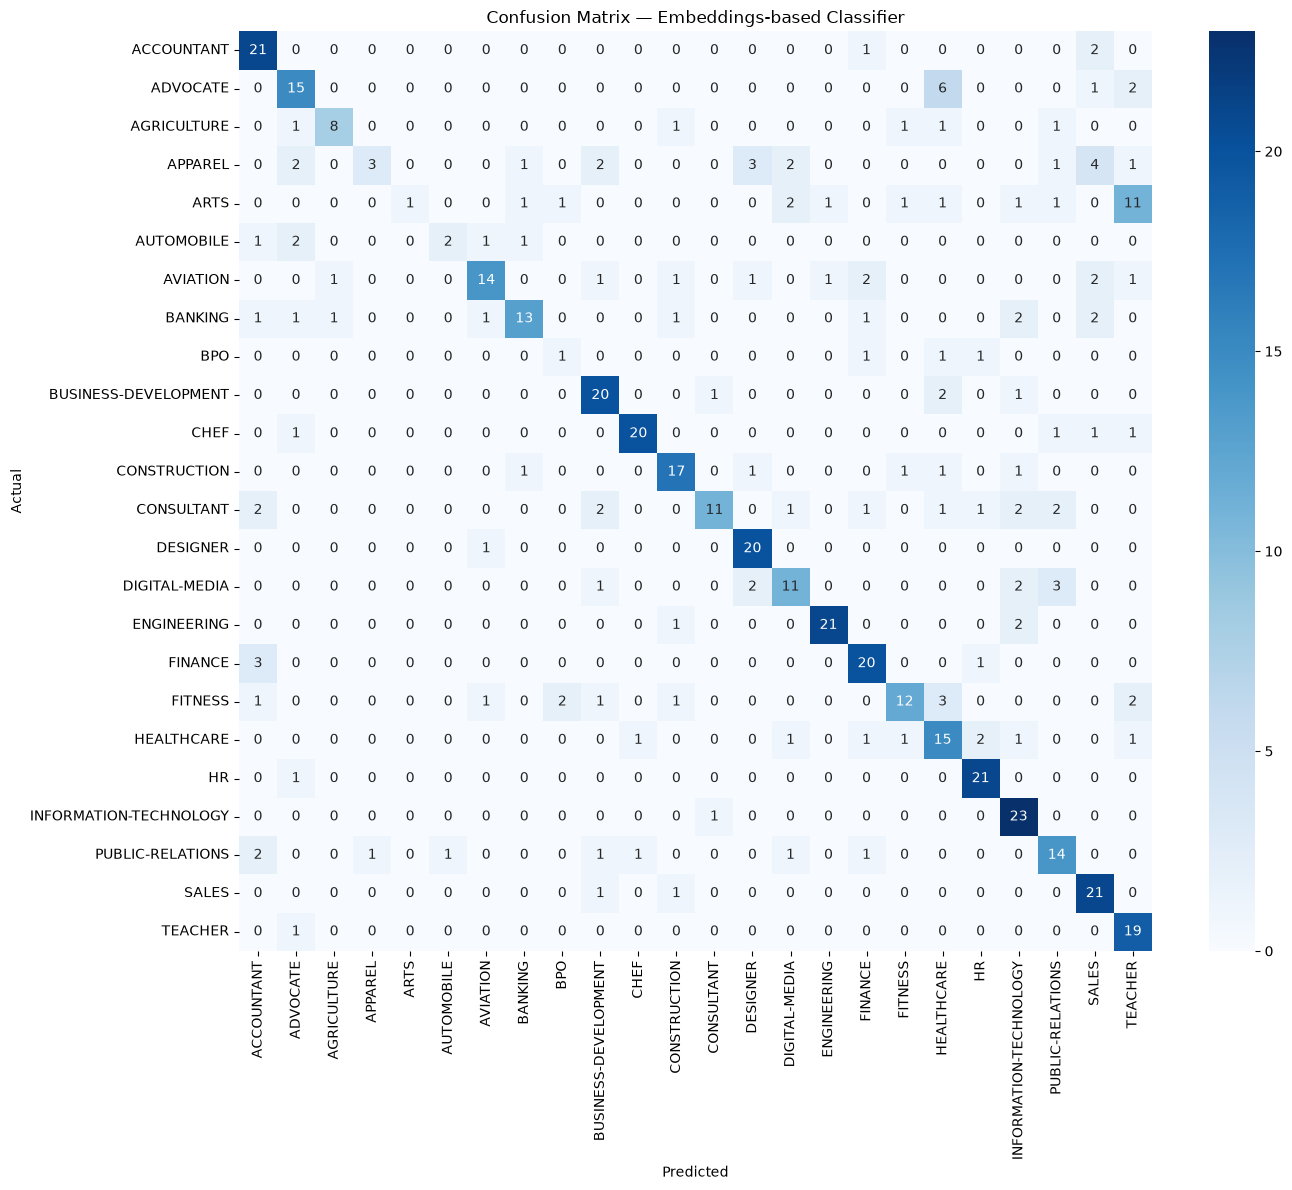

In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_emb, y_pred_emb, labels=clf_emb.classes_)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=clf_emb.classes_, yticklabels=clf_emb.classes_, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Embeddings-based Classifier")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
for c in [0.1, 0.2, 0.5, 1.0, 2.0]:
    clf_test = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced", C=c)
    clf_test.fit(X_train_emb, y_train_emb)
    tr = accuracy_score(y_train_emb, clf_test.predict(X_train_emb))
    te = accuracy_score(y_test_emb, clf_test.predict(X_test_emb))
    print(f"C={c}: Train={tr:.4f}, Test={te:.4f}, Gap={tr-te:.4f}")

C=0.1: Train=0.6930, Test=0.6700, Gap=0.0230
C=0.2: Train=0.7202, Test=0.6901, Gap=0.0300
C=0.5: Train=0.7544, Test=0.7123, Gap=0.0421
C=1.0: Train=0.7771, Test=0.7284, Gap=0.0487
C=2.0: Train=0.8143, Test=0.7243, Gap=0.0899


In [24]:
final_clf = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced", C=1.0)
final_clf.fit(X_train_emb, y_train_emb)

train_acc_final = accuracy_score(y_train_emb, final_clf.predict(X_train_emb))
test_acc_final = accuracy_score(y_test_emb, final_clf.predict(X_test_emb))
print(f"Final model — Train: {train_acc_final:.4f}, Test: {test_acc_final:.4f}, Gap: {train_acc_final - test_acc_final:.4f}")

Final model — Train: 0.7771, Test: 0.7284, Gap: 0.0487


In [25]:
import joblib

joblib.dump(final_clf, "../data/resume_classifier.joblib")
np.save("../data/resume_embeddings.npy", resume_embeddings)  # already saved, but confirming
print("Model saved.")

Model saved.


In [26]:
from dotenv import load_dotenv
import os

load_dotenv()
mistral_api_key = os.getenv("MISTRAL_API_KEY")
print("Mistral key loaded:", mistral_api_key is not None and len(mistral_api_key) > 10)

Mistral key loaded: True


In [28]:
import mistralai
print(mistralai.__file__)

None


In [29]:
from mistralai.client import Mistral

mistral_client = Mistral(api_key=mistral_api_key)

In [32]:

import json

def get_resume_critique(resume_text, job_description, match_score, predicted_category):
    prompt = f"""You are a resume reviewer. Compare this resume against the job description and give structured feedback.

RESUME:
{resume_text[:2000]}

JOB DESCRIPTION:
{job_description[:1500]}

CONTEXT: This resume has a computed match score of {match_score:.1f}% and was classified into the category "{predicted_category}".

Respond ONLY with valid JSON in exactly this format, no other text:
{{
  "strengths": ["point 1", "point 2", "point 3"],
  "gaps": ["point 1", "point 2", "point 3"],
  "suggestions": ["specific actionable suggestion 1", "specific actionable suggestion 2", "specific actionable suggestion 3"]
}}"""

    response = mistral_client.chat.complete(
        model="mistral-small-latest",
        messages=[{"role": "user", "content": prompt}]
    )

    text = response.choices[0].message.content.strip()
    text = text.replace("```json", "").replace("```", "").strip()

    return json.loads(text)

In [33]:
sample_resume_text = resumes[resumes["Category"] == "INFORMATION-TECHNOLOGY"]["Resume_str"].iloc[0]
sample_job_text = postings_sample["description"].iloc[0]

critique = get_resume_critique(
    resume_text=sample_resume_text,
    job_description=sample_job_text,
    match_score=34.83,
    predicted_category="INFORMATION-TECHNOLOGY"
)

print(json.dumps(critique, indent=2))

{
  "strengths": [
    "Strong background in Information Assurance and Risk Management Framework (RMF), which aligns with IT-focused roles",
    "Extensive experience in enterprise systems, network design, and compliance (e.g., STIG hardening, ATOs), demonstrating technical expertise",
    "Proven track record in project management and accreditation efforts, showing leadership and coordination skills"
  ],
  "gaps": [
    "The resume is entirely IT-focused, with no relevant experience or skills for a Warehouse Associate role (e.g., inventory management, shipping/receiving, warehouse operations)",
    "No mention of physical labor, equipment operation, or warehouse-specific tools/processes, which are critical for this position",
    "The job description emphasizes customer service and safety in a warehouse environment, which is not reflected in the resume"
  ],
  "suggestions": [
    "Tailor the resume to highlight transferable skills (e.g., attention to detail, process improvement, tea

In [34]:
# Use one of the actual top matches from Week 1 instead of a random job
top_matches = find_top_matches(sample_resume_text, job_embeddings, postings_sample, top_n=1)
best_job_idx = postings_sample[postings_sample["title"] == top_matches.iloc[0]["title"]].index[0]

good_match_critique = get_resume_critique(
    resume_text=sample_resume_text,
    job_description=postings_sample["description"].iloc[best_job_idx],
    match_score=top_matches.iloc[0]["similarity_score"] * 100,
    predicted_category="INFORMATION-TECHNOLOGY"
)

print(f"Job: {top_matches.iloc[0]['title']}")
print(f"Score: {top_matches.iloc[0]['similarity_score']*100:.1f}%")
print(json.dumps(good_match_critique, indent=2))

Job: Information Technology Risk Manager
Score: 62.8%
{
  "strengths": [
    "Extensive experience in Information Assurance and Risk Management Framework (RMF), which aligns with the job's focus on risk oversight and regulatory compliance.",
    "Proven track record in accreditation efforts (Authorization To Operate decisions) and vulnerability management, demonstrating expertise in control testing and regulatory requirements.",
    "Strong technical skills in Active Directory design, network troubleshooting, and Linux hardening, which are relevant to enterprise IT and security functions."
  ],
  "gaps": [
    "Lacks explicit mention of Data Governance, Data Management, or Data Analytics, which are key responsibilities in the job description.",
    "No evidence of experience with Risk and Control Self-Assessment (RCSA), Key Risk Indicators (KRI), or Targeted Assessments, which are explicitly required.",
    "No clear demonstration of knowledge of operational risk frameworks (e.g., NIST

In [35]:
import joblib

# Save the final classifier (trained on embeddings, C=1.0)
joblib.dump(final_clf, "../data/resume_classifier.joblib")

# Embeddings are already saved from earlier (resume_embeddings.npy, job_embeddings.npy)
# but let's confirm they're current
np.save("../data/resume_embeddings.npy", resume_embeddings)
np.save("../data/job_embeddings.npy", job_embeddings)

# Save postings_sample too — needed at API runtime for the matcher to have jobs to compare against
postings_sample.to_csv("../data/postings_sample_processed.csv", index=False)

print("All artifacts saved:")
print("- resume_classifier.joblib")
print("- resume_embeddings.npy")
print("- job_embeddings.npy")
print("- postings_sample_processed.csv")

All artifacts saved:
- resume_classifier.joblib
- resume_embeddings.npy
- job_embeddings.npy
- postings_sample_processed.csv
